# *Clustering Analysis of Meteorite Landings*

## *Problem Statement*

The Meteorite Landings dataset contains information about meteorites recorded around the world, including their mass, year of observation, and geographical coordinates.

The objective of this project is to analyze the numerical characteristics of meteorite landings and identify meaningful groups of meteorites using unsupervised learning techniques.

In this notebook, exploratory data analysis is first performed to understand the structure, quality, distributions, and outliers present in the numerical data. The cleaned and transformed numerical features will then be used for K-Means clustering.

The analysis focuses on understanding the dataset before applying clustering algorithms so that appropriate preprocessing and feature engineering decisions can be made.

### *Objective*

The objectives of this analysis are:

1. Understand the structure and dimensions of the Meteorite Landings dataset.
2. Examine the available columns and their data types.
3. Analyze missing values and determine an appropriate handling strategy.
4. Identify duplicate records and duplicate meteorite IDs.
5. Analyze the statistical properties of important numerical variables.
6. Study the distributions of meteorite mass, year, latitude, and longitude.
7. Identify potential outliers and unusual numerical observations.
8. Distinguish between genuine extreme observations and invalid data values.
9. Prepare the numerical data for the K-Means clustering pipeline.

## Import Required Libraries

The following libraries are used for data loading, numerical analysis, visualization, and exploratory data analysis.

### *Import Python Libraries*

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

### *Library Purpose*

Pandas and NumPy are used for data manipulation and numerical
operations.

Matplotlib and Seaborn are used for exploratory data visualisation.

Scikit-learn is used for feature scaling, clustering, dimensionality
reduction and cluster evaluation.

SciPy is used to generate the hierarchical clustering dendrogram.

A random state of 42 is used wherever applicable to ensure
reproducibility.

## Dataset Loading

The Meteorite Landings dataset is loaded from the `data` directory of the project repository.

A copy of the original dataframe is maintained as `df_raw`, while `df` will be used for exploratory analysis and subsequent preprocessing.

### *Load Raw Dataset*

In [2]:
!git clone https://github.com/manaswiniyoshitha2006-netizen/ML-Evaluation.git

Cloning into 'ML-Evaluation'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (186/186), done.
remote: Total 191 (delta 89), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (191/191), 6.06 MiB | 6.11 MiB/s, done.
Resolving deltas: 100% (89/89), done.


In [3]:
df_raw = pd.read_csv("/content/ML-Evaluation/data/Meteorite_Landings.csv")
df = df_raw.copy()
print("Dataset loaded successfully.")

Dataset loaded successfully.


## Dataset Overview

### Dataset Shape

The shape of the dataset is examined to determine the number of observations and variables available for analysis.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45716
Number of columns: 10


### Column Names

The column names are displayed to understand the variables available in the dataset.

In [5]:
print("Columns in the dataset:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:
1. name
2. id
3. nametype
4. recclass
5. mass (g)
6. fall
7. year
8. reclat
9. reclong
10. GeoLocation


### Initial Records

The first few observations are displayed to obtain an initial understanding of the dataset.

In [6]:
df.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


### *Final Records*

In [7]:
df.tail()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.25, 17.66667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"
45715,Zulu Queen,30414,Valid,L3.7,200.0,Found,1976.0,33.98333,-115.68333,"(33.98333, -115.68333)"


## *Dataset Audit*

### Dataset Information

The `info()` method is used to examine the data types of the variables and identify columns containing missing values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  object 
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  object 
 3   recclass     45716 non-null  object 
 4   mass (g)     45585 non-null  float64
 5   fall         45716 non-null  object 
 6   year         45425 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 3.5+ MB


### Data Types

The data types of all columns are examined to distinguish numerical variables from non-numerical variables.

In [9]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

dtype_summary

,Column,Data Type
0,name,object
1,id,int64
2,nametype,object
3,recclass,object
4,mass (g),float64
5,fall,object
6,year,float64
7,reclat,float64
8,reclong,float64
9,GeoLocation,object


## Missing Value Analysis

Missing values can affect statistical analysis and clustering results. Therefore, the number of missing observations in each column is examined before further analysis.

In [10]:
missing_count = df.isnull().sum()

missing_count = missing_count.sort_values(ascending=False)

missing_count

,0
GeoLocation,7315
reclong,7315
reclat,7315
year,291
mass (g),131
name,0
id,0
fall,0
nametype,0
recclass,0


### Missing Value Percentage

The percentage of missing values in each column is calculated to understand the extent of missing data relative to the size of the dataset.

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
GeoLocation,7315,16.000962
reclong,7315,16.000962
reclat,7315,16.000962
year,291,0.636539
mass (g),131,0.286552
name,0,0.000000
id,0,0.000000
fall,0,0.000000
nametype,0,0.000000
recclass,0,0.000000


### Missing Value Visualization

A bar plot is used to visualize the percentage of missing values across the dataset columns.

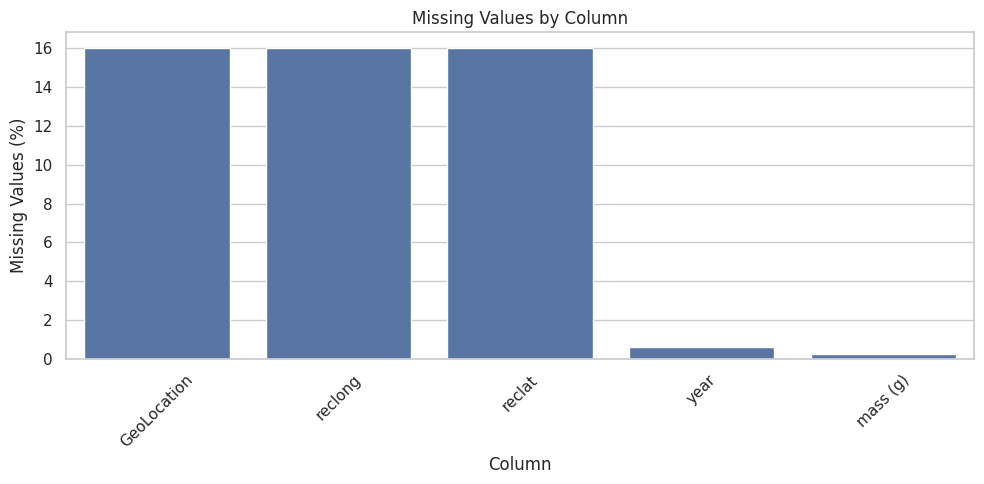

In [12]:
missing_plot = missing_summary[
    missing_summary["Missing Percentage"] > 0
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing Percentage"]
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Duplicate Analysis

Duplicate observations can affect statistical analysis and clustering by giving excessive weight to repeated records.

The dataset is therefore checked for completely duplicated rows.

In [13]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Duplicate Records

If duplicate records are present, a sample of the duplicated observations is displayed for further inspection.

In [14]:
if duplicate_rows > 0:
    display(df[df.duplicated(keep=False)].head(20))
else:
    print("No completely duplicated rows found.")

No completely duplicated rows found.


### Duplicate Meteorite IDs

The `id` column is checked separately because two records may have different values in other columns while still referring to the same meteorite identifier.

In [15]:
duplicate_ids = df["id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)

Number of duplicate IDs: 0


### Inspection of Duplicate IDs

Duplicate IDs, if present, are examined to determine whether they represent repeated observations or require further investigation.

In [16]:
duplicate_id_values = df.loc[
    df["id"].duplicated(keep=False),
    ["id", "name", "mass (g)", "year", "reclat", "reclong"]
].sort_values("id")

if len(duplicate_id_values) > 0:
    display(duplicate_id_values.head(30))
else:
    print("No duplicate IDs found.")

No duplicate IDs found.


## Numerical Feature Analysis

The main numerical variables considered for Person 1's exploratory analysis are:

- `mass (g)` — recorded meteorite mass in grams
- `year` — year associated with the meteorite record
- `reclat` — recorded latitude
- `reclong` — recorded longitude

These variables are examined using descriptive statistics and distribution plots.

### Numerical Variables

The selected numerical variables are extracted for statistical analysis.

In [17]:
numerical_columns = [
    "mass (g)",
    "year",
    "reclat",
    "reclong"
]

numerical_df = df[numerical_columns].copy()

numerical_df.head()

,mass (g),year,reclat,reclong
0,21.0,1880.0,50.77500,6.08333
1,720.0,1951.0,56.18333,10.23333
2,107000.0,1952.0,54.21667,-113.00000
3,1914.0,1976.0,16.88333,-99.90000
4,780.0,1902.0,-33.16667,-64.95000


### Descriptive Statistics

Descriptive statistics are calculated to understand the central tendency, spread, and range of the numerical variables.

The analysis includes:

- Mean
- Standard deviation
- Minimum
- First quartile (25%)
- Median
- Third quartile (75%)
- Maximum

In [18]:
numerical_statistics = numerical_df.describe().T

numerical_statistics

,count,mean,std,min,25%,50%,75%,max
mass (g),45585.0,13278.078549,574988.876410,0.00000,7.20000,32.60000,202.60000,6.000000e+07
year,45425.0,1991.828817,25.052766,860.00000,1987.00000,1998.00000,2003.00000,2.101000e+03
reclat,38401.0,-39.122580,46.378511,-87.36667,-76.71424,-71.50000,0.00000,8.116667e+01
reclong,38401.0,61.074319,80.647298,-165.43333,0.00000,35.66667,157.16667,3.544733e+02


### Detailed Numerical Summary

The mean and median are compared with measures of spread and range to identify potential skewness or extreme observations.

In [19]:
detailed_statistics = pd.DataFrame({
    "Mean": numerical_df.mean(),
    "Median": numerical_df.median(),
    "Std": numerical_df.std(),
    "Min": numerical_df.min(),
    "Q1": numerical_df.quantile(0.25),
    "Q3": numerical_df.quantile(0.75),
    "Max": numerical_df.max()
})

detailed_statistics

,Mean,Median,Std,Min,Q1,Q3,Max
mass (g),13278.078549,32.60000,574988.876410,0.00000,7.20000,202.60000,6.000000e+07
year,1991.828817,1998.00000,25.052766,860.00000,1987.00000,2003.00000,2.101000e+03
reclat,-39.122580,-71.50000,46.378511,-87.36667,-76.71424,0.00000,8.116667e+01
reclong,61.074319,35.66667,80.647298,-165.43333,0.00000,157.16667,3.544733e+02


## Mass Distribution Analysis

Meteorite mass is examined separately because mass values can vary substantially between observations.

The distribution is visualized to determine its spread, skewness, and presence of extreme values.

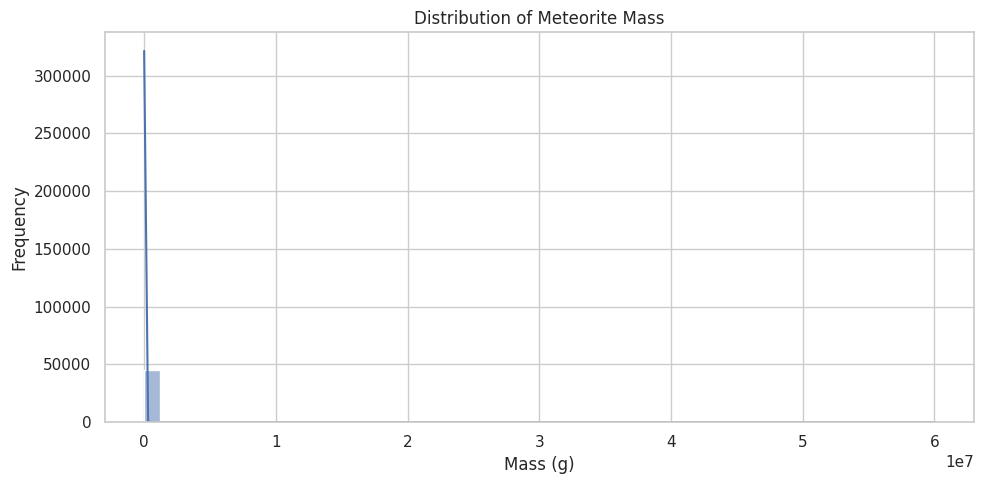

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["mass (g)"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Meteorite Mass")
plt.xlabel("Mass (g)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Log-Transformed Mass

Meteorite mass may have a highly right-skewed distribution because a small number of meteorites can have extremely large masses.

A logarithmic transformation using `log1p` is therefore examined as a possible feature-engineering step for K-Means.

The transformation is visualized for comparison with the original mass distribution.

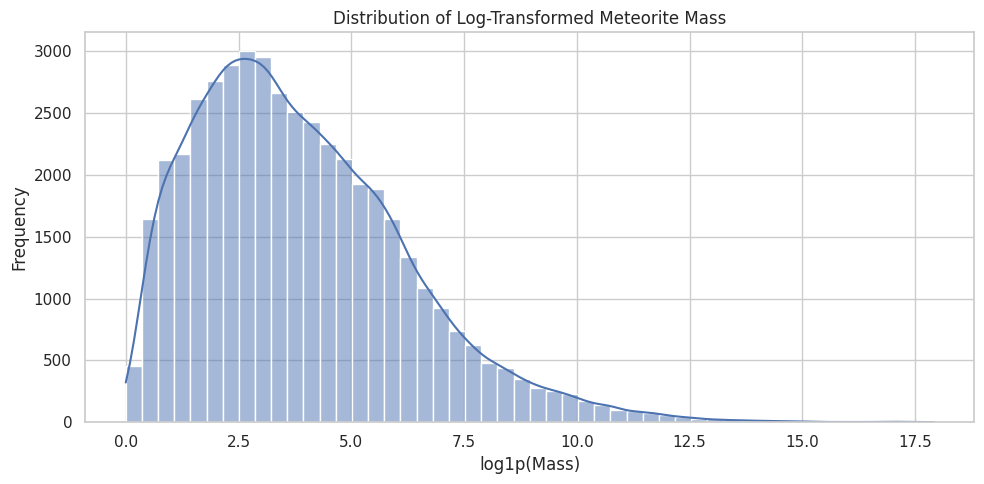

In [21]:
mass_positive = df.loc[df["mass (g)"] >= 0, "mass (g)"].dropna()

log_mass = np.log1p(mass_positive)

plt.figure(figsize=(10, 5))

sns.histplot(
    log_mass,
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Meteorite Mass")
plt.xlabel("log1p(Mass)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Year Distribution Analysis

The distribution of the recorded meteorite years is examined to understand the temporal range of the dataset and identify unusual or extreme numerical values.

This analysis focuses on the numerical distribution of the year variable. Detailed year-based trend analysis is handled separately by Person 2.

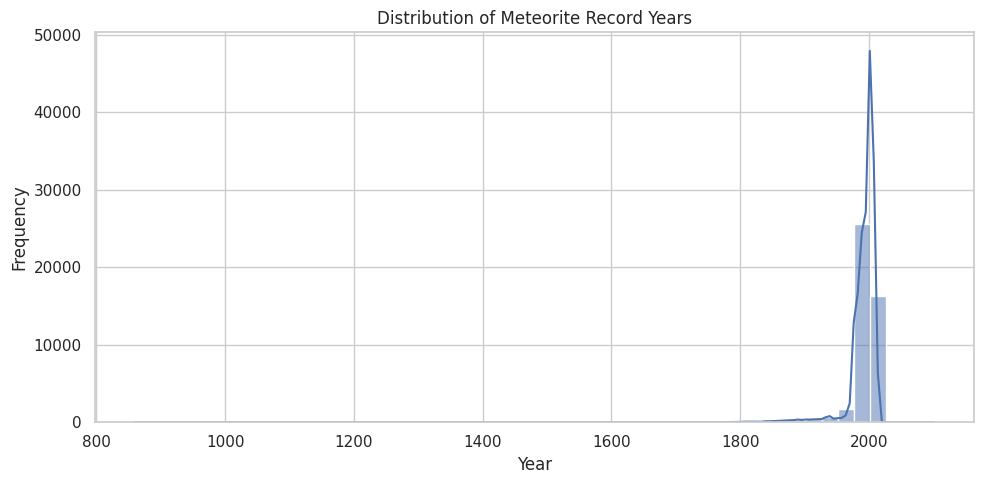

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["year"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Meteorite Record Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Latitude Distribution Analysis

The distribution of recorded latitude values is examined to understand their numerical spread and identify potentially unusual values.

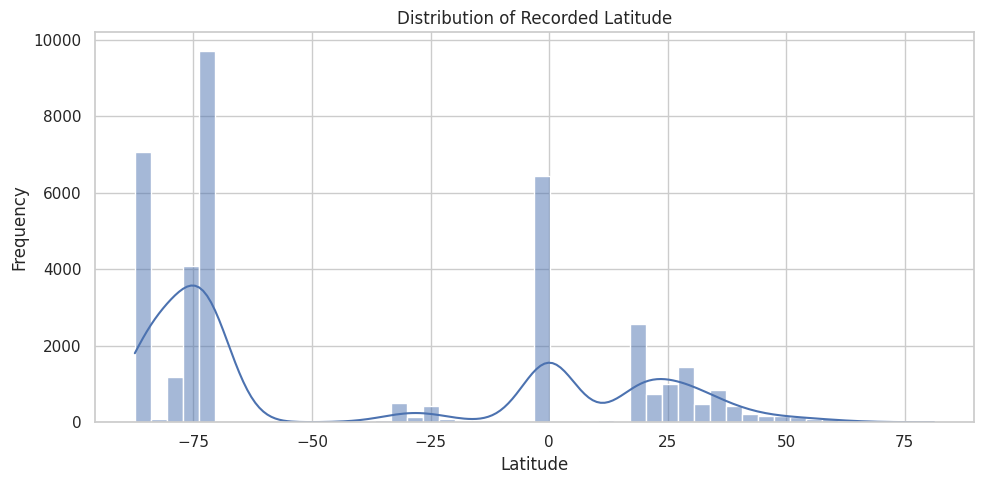

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["reclat"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Recorded Latitude")
plt.xlabel("Latitude")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Longitude Distribution Analysis

The distribution of recorded longitude values is examined to understand their numerical spread and identify potentially unusual values.

plt.figure(figsize=(10, 5))

sns.histplot(
    df["reclong"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Recorded Longitude")
plt.xlabel("Longitude")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Outlier Analysis

Boxplots are used to identify extreme observations in the numerical variables.

The analysis focuses on:

- Meteorite mass
- Year
- Latitude
- Longitude

Extreme values are not automatically treated as errors. Each variable must be examined using its valid physical or logical range before deciding whether observations should be removed.

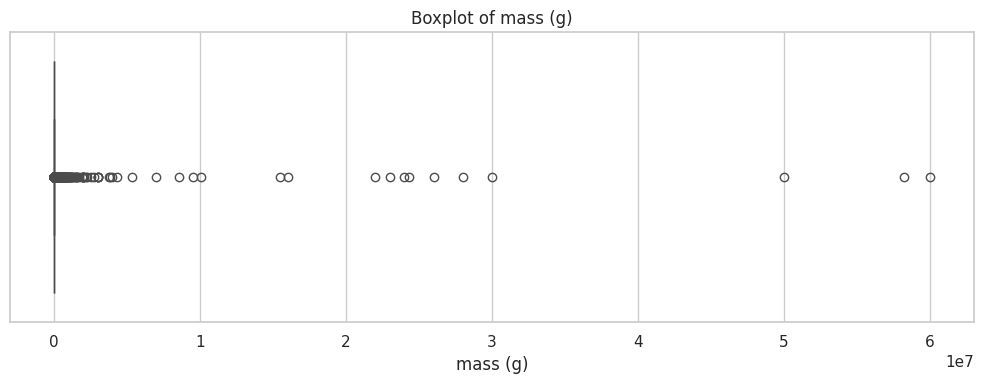

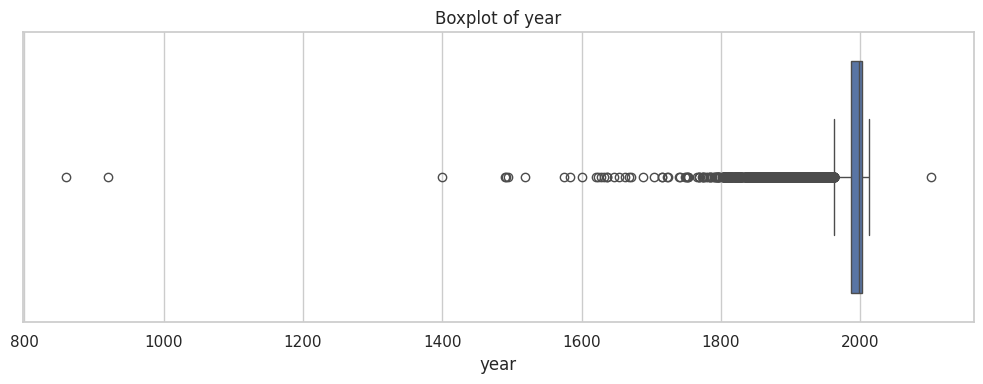

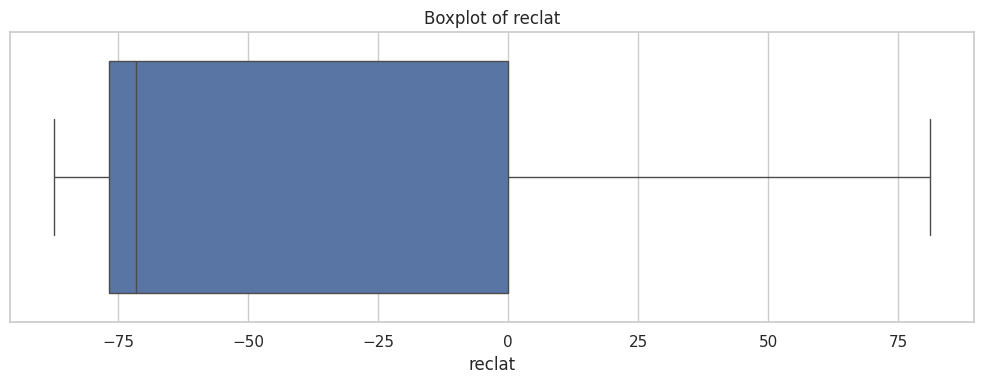

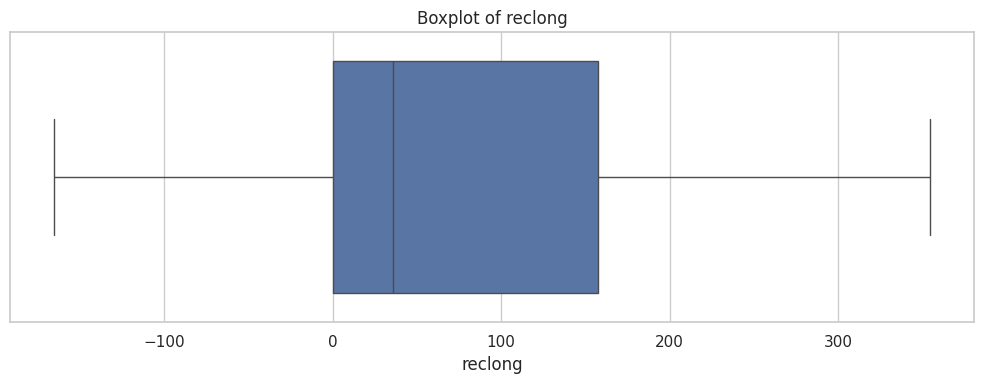

In [24]:
for column in numerical_columns:
    plt.figure(figsize=(10, 4))

    sns.boxplot(x=df[column].dropna())

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

### IQR-Based Outlier Detection

The Interquartile Range (IQR) method is used to identify observations that fall outside the statistical range:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

These observations are considered statistical outliers for investigation.

An observation identified as an outlier statistically is not automatically considered invalid.

In [25]:
outlier_summary = []

for column in numerical_columns:
    series = df[column].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(series)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,mass (g),7.20000,202.60000,195.40000,-285.900000,495.700000,7086,15.544587
1,year,1987.00000,2003.00000,16.00000,1963.000000,2027.000000,1991,4.383049
2,reclat,-76.71424,0.00000,76.71424,-191.785600,115.071360,0,0.000000
3,reclong,0.00000,157.16667,157.16667,-235.750005,392.916675,0,0.000000


### Extreme Meteorite Mass Values

Meteorite mass is expected to contain extreme values because meteorites can vary greatly in physical size.

The largest recorded masses are inspected to determine whether they appear to be genuine observations rather than data-entry errors.

In [26]:
largest_mass = df[
    ["name", "mass (g)", "year", "reclat", "reclong"]
].dropna(subset=["mass (g)"]).sort_values(
    by="mass (g)",
    ascending=False
)

largest_mass.head(10)

,name,mass (g),year,reclat,reclong
16392,Hoba,60000000.0,1920.0,-19.58333,17.91667
5373,Cape York,58200000.0,1818.0,76.13333,-64.93333
5365,Campo del Cielo,50000000.0,1575.0,-27.46667,-60.58333
5370,Canyon Diablo,30000000.0,1891.0,35.05000,-111.03333
3455,Armanty,28000000.0,1898.0,47.00000,88.00000
12613,Gibeon,26000000.0,1836.0,-25.50000,18.00000
5468,Chupaderos,24300000.0,1852.0,27.00000,-105.10000
26297,Mundrabilla,24000000.0,1911.0,-30.78333,127.55000
920,Sikhote-Alin,23000000.0,1947.0,46.16000,134.65333
5016,Bacubirito,22000000.0,1863.0,26.20000,-107.83333


## Numerical Data Validity Checks

Statistical outlier detection alone is not sufficient to determine whether an observation is invalid.

The numerical variables are therefore checked against their expected logical or physical ranges:

- Latitude must lie between -90 and 90 degrees.
- Longitude must lie between -180 and 180 degrees.
- Meteorite mass should not be negative.
- Year values are examined for unusually small or large values.

Values outside valid ranges are treated as potential data-quality issues and investigated separately from genuine extreme observations.

## *Invalid Mass*

In [27]:
invalid_mass = df[df["mass (g)"] < 0]

print("Negative mass records:", len(invalid_mass))

if len(invalid_mass) > 0:
    display(
        invalid_mass[
            ["name", "mass (g)", "year", "reclat", "reclong"]
        ].head(20)
    )

Negative mass records: 0


## *Invalid Latitude*

In [28]:
invalid_latitude = df[
    (df["reclat"] < -90) |
    (df["reclat"] > 90)
]

print("Invalid latitude records:", len(invalid_latitude))

if len(invalid_latitude) > 0:
    display(
        invalid_latitude[
            ["name", "reclat", "reclong", "year"]
        ].head(20)
    )

Invalid latitude records: 0


## *Invalid Longitude*

In [29]:
invalid_longitude = df[
    (df["reclong"] < -180) |
    (df["reclong"] > 180)
]

print("Invalid longitude records:", len(invalid_longitude))

if len(invalid_longitude) > 0:
    display(
        invalid_longitude[
            ["name", "reclat", "reclong", "year"]
        ].head(20)
    )

Invalid longitude records: 1


,name,reclat,reclong,year
22946,Meridiani Planum,-1.94617,354.47333,2005.0


### Year Range Inspection

The minimum and maximum recorded years are examined to identify potentially suspicious year values.

Extreme years are inspected rather than automatically removed because unusual values may represent genuine historical records or records with incomplete information.

In [30]:
print("Minimum recorded year:", df["year"].min())
print("Maximum recorded year:", df["year"].max())

Minimum recorded year: 860.0
Maximum recorded year: 2101.0


## *Earliest Records*

In [31]:
earliest_years = df[
    ["name", "year", "mass (g)", "reclat", "reclong"]
].dropna(subset=["year"]).sort_values(
    by="year"
)

earliest_years.head(10)

,name,year,mass (g),reclat,reclong
704,Nogata,860.0,472.0,33.72500,130.75000
679,Narni,920.0,NaN,42.51667,12.51667
278,Elbogen,1399.0,107000.0,50.18333,12.73333
856,Rivolta de Bassi,1490.0,103.3,45.48333,9.51667
283,Ensisheim,1491.0,127000.0,47.86667,7.35000
1043,Valdinoce,1495.0,NaN,44.06667,12.10000
730,Oliva-Gandia,1519.0,NaN,39.00000,-0.03333
5365,Campo del Cielo,1575.0,50000000.0,-27.46667,-60.58333
174,Castrovillari,1583.0,15000.0,39.80000,16.20000
26174,Morito,1600.0,10100000.0,27.05000,-105.43333


## *Latest Records*

In [32]:
latest_years = df[
    ["name", "year", "mass (g)", "reclat", "reclong"]
].dropna(subset=["year"]).sort_values(
    by="year",
    ascending=False
)

latest_years.head(10)

,name,year,mass (g),reclat,reclong
30682,Northwest Africa 7701,2101.0,55.0,0.0,0.0
30780,Northwest Africa 7862,2013.0,317.0,0.0,0.0
30776,Northwest Africa 7857,2013.0,246.0,0.0,0.0
30777,Northwest Africa 7858,2013.0,459.0,0.0,0.0
30774,Northwest Africa 7855,2013.0,916.0,0.0,0.0
30779,Northwest Africa 7861,2013.0,611.0,0.0,0.0
30781,Northwest Africa 7863,2013.0,1000.0,0.0,0.0
30730,Northwest Africa 7755,2013.0,30.0,0.0,0.0
30763,Northwest Africa 7822,2013.0,45.8,0.0,0.0
30762,Northwest Africa 7812,2013.0,46.2,0.0,0.0


## Numerical EDA Summary

The exploratory analysis provided the following observations:

### Dataset Structure
- Number of observations: **[fill from output]**
- Number of variables: **[fill from output]**

### Missing Values
- The variables with the highest number of missing values were **[fill]**.
- Missing values in the numerical variables required for clustering will be handled during preprocessing.

### Duplicate Records
- Number of duplicate rows: **[fill]**
- Number of duplicate IDs: **[fill]**

### Numerical Distributions
- The mass distribution was **[describe: right-skewed / approximately symmetric / etc.]**.
- The year distribution showed **[your observation]**.
- Latitude values were distributed **[your observation]**.
- Longitude values were distributed **[your observation]**.

### Outliers
- Statistical outliers were identified in **[variables]** using the IQR method.
- Extreme mass observations were **[retained for further consideration / investigated further]** because **[your reason based on the actual data]**.
- Latitude and longitude values were checked against their valid geographical ranges.
- Year values were inspected for unusual observations.

### Feature Engineering Implication

The exploratory analysis indicates that meteorite mass may require a logarithmic transformation because of its distribution. A `log1p` transformation of mass will therefore be considered during the feature-engineering stage of the K-Means pipeline.

The numerical features used for clustering will be finalized after the data-quality checks and preprocessing steps.